Best PSNR: 18.30 achieved by median (Constant)


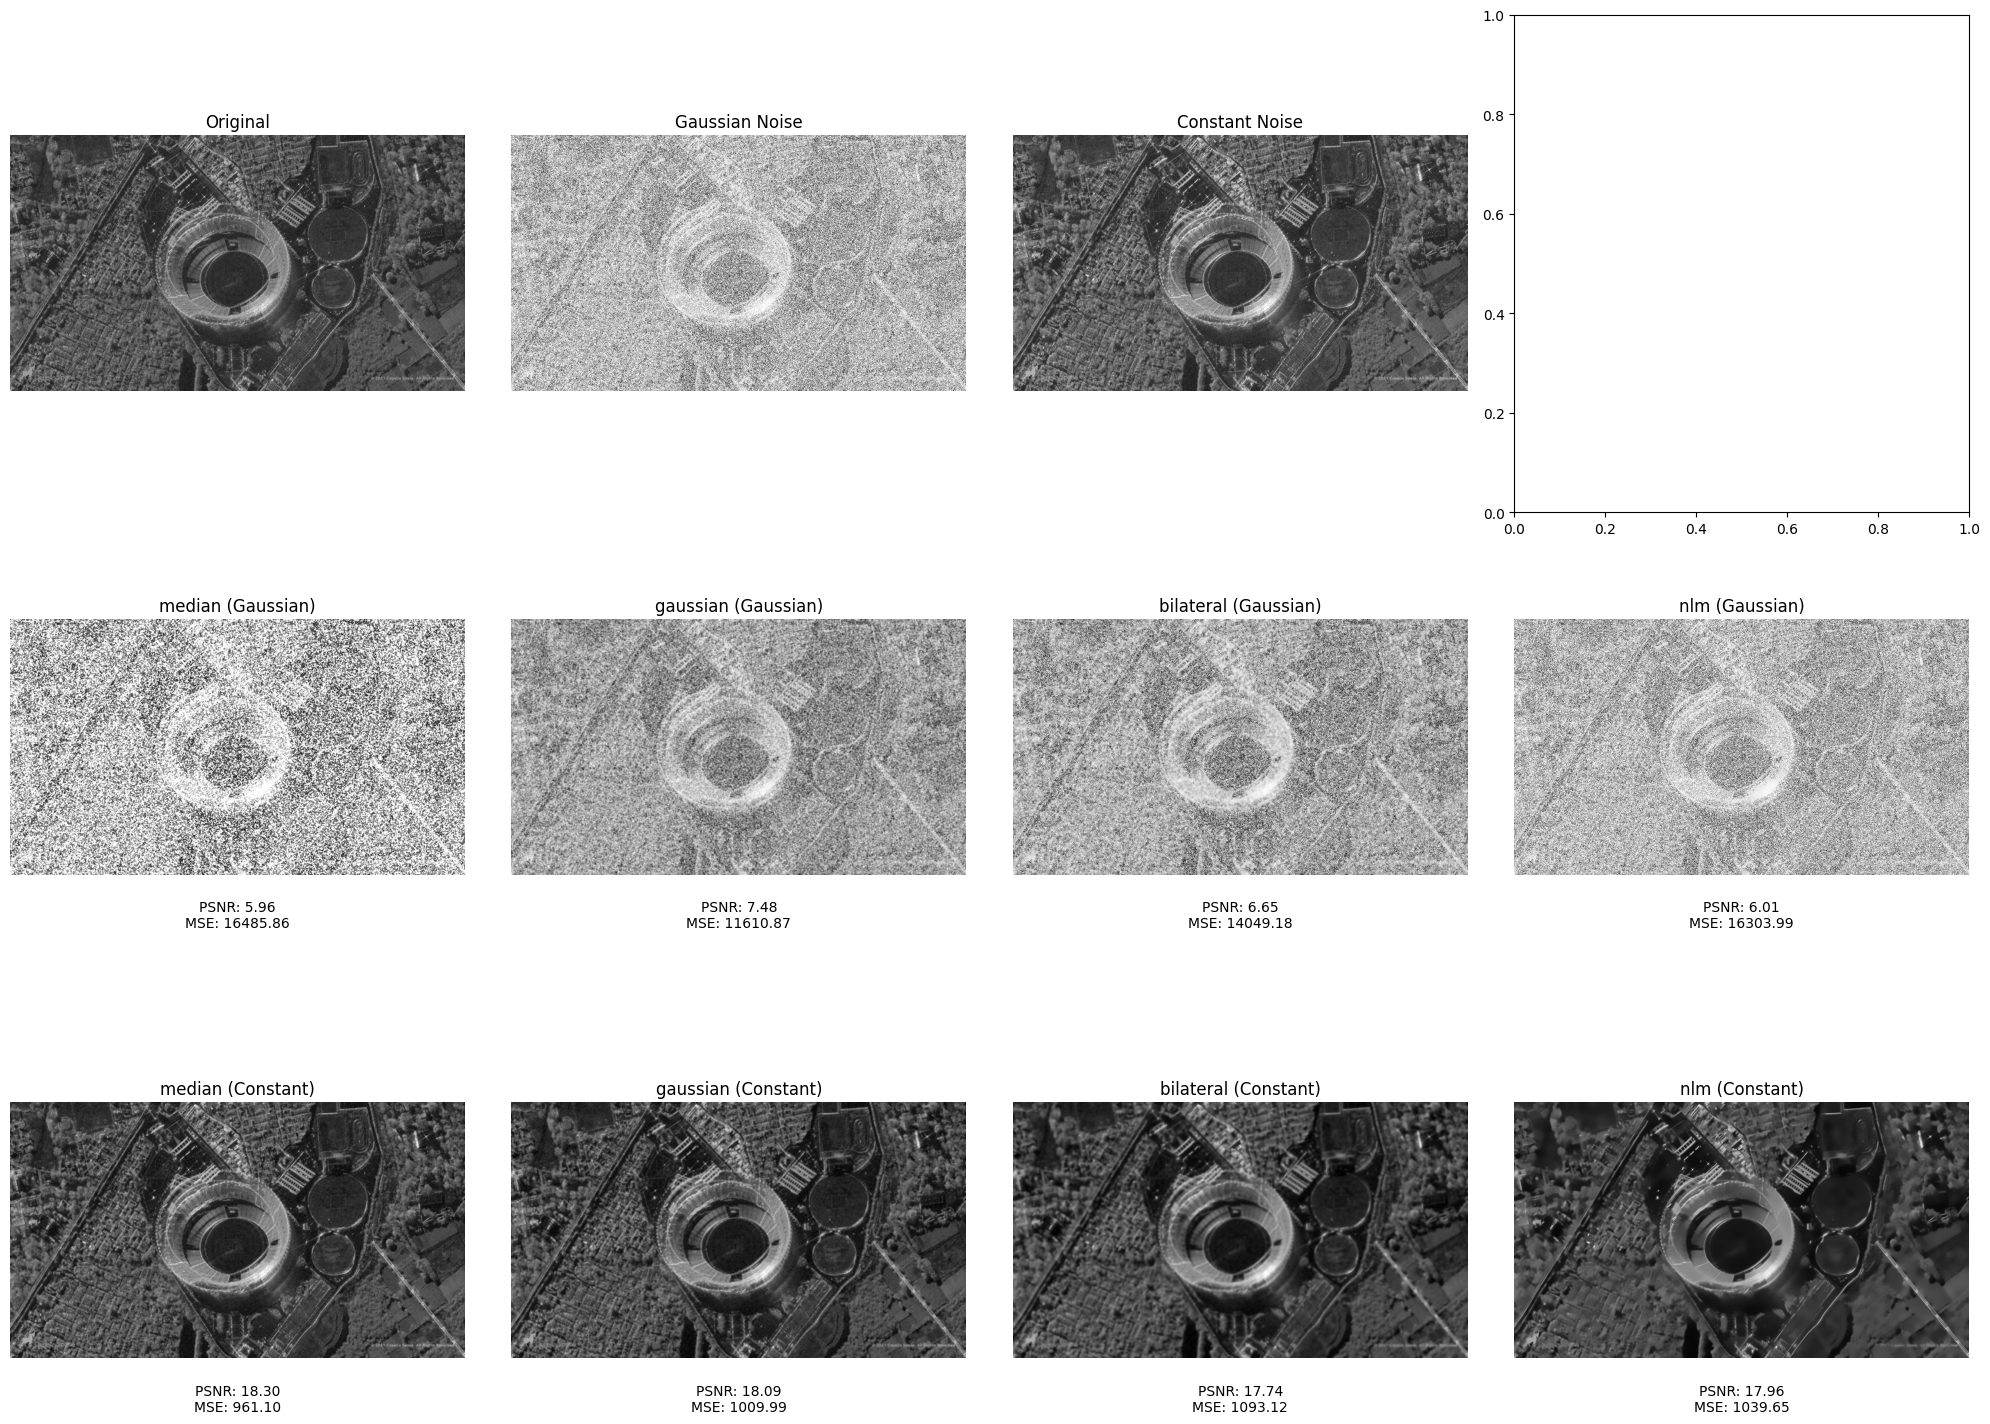

In [14]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage.metrics import peak_signal_noise_ratio as psnr, mean_squared_error

# Функция добавления шумов
def add_gaussian_noise(image, mean=0, stddev=50):
    noise = np.random.normal(mean, stddev, image.shape).astype(np.uint8)
    return cv2.add(image, noise)

def add_constant_noise(image, value=30):
    noise = np.ones(image.shape, np.uint8) * value
    return cv2.add(image, noise)

# Фильтры с разными параметрами
def apply_filters(image):
    filters = {
        "median": cv2.medianBlur(image, 3),
        "gaussian": cv2.GaussianBlur(image, (5, 5), 0),
        "bilateral": cv2.bilateralFilter(image, 9, 75, 75),
        "nlm": cv2.fastNlMeansDenoising(image, h=20),
    }
    return filters

# Оценка качества фильтрации
def evaluate_filters(original, noisy, filters):
    results = {}
    for name, filtered in filters.items():
        results[name] = {
            "MSE": mean_squared_error(original, filtered),
            "PSNR": psnr(original, filtered)
        }
    return results

# Загрузка изображения
image = cv2.imread('sar_1.jpg', cv2.IMREAD_GRAYSCALE)

# Добавление шумов
image_gauss = add_gaussian_noise(image)
image_const = add_constant_noise(image)

# Применение фильтров
filters_gauss = apply_filters(image_gauss)
filters_const = apply_filters(image_const)

# Оценка качества фильтров
results_gauss = evaluate_filters(image, image_gauss, filters_gauss)
results_const = evaluate_filters(image, image_const, filters_const)

# Вывод изображений с использованием matplotlib
fig, axes = plt.subplots(3, 4, figsize=(20, 15))

axes[0, 0].imshow(image, cmap='gray')
axes[0, 0].set_title("Original")
axes[0, 0].axis('off')

axes[0, 1].imshow(image_gauss, cmap='gray')
axes[0, 1].set_title("Gaussian Noise")
axes[0, 1].axis('off')

axes[0, 2].imshow(image_const, cmap='gray')
axes[0, 2].set_title("Constant Noise")
axes[0, 2].axis('off')

# Применение фильтров и отображение результатов
best_psnr = -float('inf')  # Переменная для хранения лучшего PSNR
best_psnr_filter = ""  # Переменная для хранения названия фильтра с лучшим PSNR

for i, (key, img) in enumerate(filters_gauss.items()):
    ax = axes[1, i]
    ax.imshow(img, cmap='gray')
    ax.set_title(f"{key} (Gaussian)")
    ax.axis('off')
    mse = results_gauss[key]["MSE"]
    psnr_value = results_gauss[key]["PSNR"]
    ax.text(0.5, -0.1, f"PSNR: {psnr_value:.2f}\nMSE: {mse:.2f}", ha='center', va='top', transform=ax.transAxes)

    # Обновляем лучший PSNR
    if psnr_value > best_psnr:
        best_psnr = psnr_value
        best_psnr_filter = f"{key} (Gaussian)"

for i, (key, img) in enumerate(filters_const.items()):
    ax = axes[2, i]
    ax.imshow(img, cmap='gray')
    ax.set_title(f"{key} (Constant)")
    ax.axis('off')
    mse = results_const[key]["MSE"]
    psnr_value = results_const[key]["PSNR"]
    ax.text(0.5, -0.1, f"PSNR: {psnr_value:.2f}\nMSE: {mse:.2f}", ha='center', va='top', transform=ax.transAxes)

    # Обновляем лучший PSNR
    if psnr_value > best_psnr:
        best_psnr = psnr_value
        best_psnr_filter = f"{key} (Constant)"

# Выводим лучший PSNR в конце
print(f"Best PSNR: {best_psnr:.2f} achieved by {best_psnr_filter}")

plt.tight_layout()
plt.show()
